# Evaluación práctica · Machine Learning · 3 puntos

**Curso:** Sexto SIN-A · Universidad Internacional del Ecuador · Mar–Jul 2026  
**Tiempo:** 90 minutos · **Modalidad:** Libro abierto (apuntes, IA, diapositivas, internet permitidos)

---

## ⚠️ Lea esto ANTES de empezar

Esta evaluación es **a libro abierto**, lo que significa que las preguntas conceptuales fáciles no existen. Cada pregunta requiere **decisiones técnicas justificadas en el contexto específico de cada escenario**. ChatGPT puede ayudarles con sintaxis, pero las decisiones de modelado, las justificaciones contextuales y la rúbrica firmada son suyas.

## Reglas de entrega

1. **Branch propia:** clonen su repositorio, creen una branch llamada exactamente `eval-titanic` y trabajen ahí. No hagan merge a `metrics` ni a `main`.
2. **Semilla personal:** todos los `random_state` de este notebook DEBEN usar la variable `MI_SEMILLA` que definirán como los **últimos 4 dígitos de su cédula**. Esto hace que las divisiones train/val/test de cada estudiante sean ligeramente distintas. Quien copie números de otro será detectable.
3. **Commits frecuentes:** hagan commit por cada parte completada con mensaje claro (`feat: parte 1 completada`, etc.). El historial de commits es parte de la evaluación.
4. **Push al terminar:** hagan `git push origin eval-titanic` cuando terminen. El timestamp del último commit en GitHub es la hora oficial de entrega.
5. **Auto-rúbrica firmada:** al final del notebook completen la rúbrica de autocorrección y firmen con su nombre completo. Sin firma, la entrega no se considera válida.

## Puntuación

| Parte | Tema | Puntos |
|---|---|---|
| 1 | Pipeline completo aplicado a Titanic | 1.5 |
| 2 | Find the bug + Predict the output | 0.75 |
| 3 | Trade-offs de negocio escritos | 0.75 |
| **Total** | | **3.0** |

---

In [1]:
# Imports — NO modificar esta celda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, classification_report
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

## 🔑 Semilla personal (OBLIGATORIO)

Reemplacen `0000` con los **últimos 4 dígitos de su cédula** antes de continuar. Esta semilla se usa en TODOS los `random_state` del notebook.

In [17]:
# REEMPLAZAR CON ÚLTIMOS 4 DÍGITOS DE SU CÉDULA
MI_SEMILLA = 1607  # ← cambiar aquí

# Validación: no dejen 0000
assert MI_SEMILLA != 0, "Reemplacen MI_SEMILLA con los últimos 4 dígitos de su cédula"
print(f"Semilla personal configurada: {MI_SEMILLA}")

Semilla personal configurada: 1607


---

# 📊 PARTE 1 — Pipeline completo aplicado (1.5 puntos · ~50 min)

## Escenario de negocio

**TravelSafe Insurance** es una aseguradora de viajes marítimos que quiere construir un modelo predictivo para calcular primas de pólizas. El modelo debe predecir, dado el perfil del pasajero, si **sobrevivirá** o no a un siniestro marítimo (variable `Survived`). 

Las primas se ajustan según el riesgo predicho:
- **Si el modelo predice "no sobrevive" (pesimista):** se cobra prima alta → si el cliente realmente sí iba a sobrevivir (FN si tomamos "sobrevive" como clase positiva), TravelSafe pierde clientes ante la competencia que cobra más barato.
- **Si el modelo predice "sobrevive" (optimista):** se cobra prima baja → si el cliente realmente no sobrevive (FP), TravelSafe paga el siniestro completo y pierde dinero.

Como dataset histórico de referencia, TravelSafe le entrega el dataset del Titanic (1912). Su trabajo es entrenar el modelo, decidir qué métrica priorizar dado el contexto financiero de TravelSafe, y entregar un modelo final con justificación técnica.

> **Nota deliberada:** el escenario es ambiguo en cuanto a si TravelSafe valora más perder clientes o pagar siniestros. **Ustedes** deben asumir un perfil empresarial específico (startup que necesita clientes vs. aseguradora establecida que minimiza riesgo) y justificarlo.

---

## 1.1 Carga y exploración inicial (0.1 pts)

Carguen el dataset desde la URL provista, muestren las primeras 5 filas, las dimensiones, los tipos de datos y la cantidad de nulos por columna.

In [3]:
# 1.1 Cargar dataset desde URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# COMPLETAR: carguen el dataset, muestren shape, head, dtypes, nulos
df = pd.read_csv(url)

print("Dimensiones del dataset:", df.shape)
display(df.head())
print("\nTipos de datos:")
display(df.dtypes)

print("\nValores nulos por columna:")
display(df.isnull().sum())

Dimensiones del dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Tipos de datos:


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


Valores nulos por columna:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 1.2 EDA dirigido (0.2 pts)

Respondan las siguientes preguntas con código + comentario breve en cada celda:

1. ¿Cuál es la tasa base de supervivencia? ¿El dataset está balanceado?

La tasa base de supervivencia es aproximadamente del 38.38%, por lo que el dataset no está perfectamente balanceado, hay más pasajeros que no sobrevivieron que pasajeros que sí sobrevivieron.

2. ¿Qué columnas tienen valores nulos y en qué proporción? ¿Cuáles deberían imputarse, cuáles eliminarse, y por qué?

Las columnas con nulos principales son Cabin, Age y Embarked
Cabin tiene demasiados valores faltantes, por lo que conviene eliminarla
Age se puede imputar porque es una variable importante para el perfil del pasajero
Embarked tiene pocos nulos, por lo que se puede imputar con la moda.

3. Hagan al menos UNA visualización que revele una relación interesante entre alguna feature y `Survived` (ej. supervivencia por sexo, por clase, por edad, etc.) y comenten lo que ven en una línea de markdown.

La gráfica muestra que los pasajeros de primera clase tuvieron una mayor tasa de supervivencia, mientras que los pasajeros de tercera clase presentaron la menor supervivencia, lo que sugiere que la clase social influyó en las probabilidades de sobrevivir

Tasa base de supervivencia: 0.3838
Porcentaje de supervivencia: 38.38

Distribución de clases:


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Cabin       0.771044
Age         0.198653
Embarked    0.002245
dtype: float64

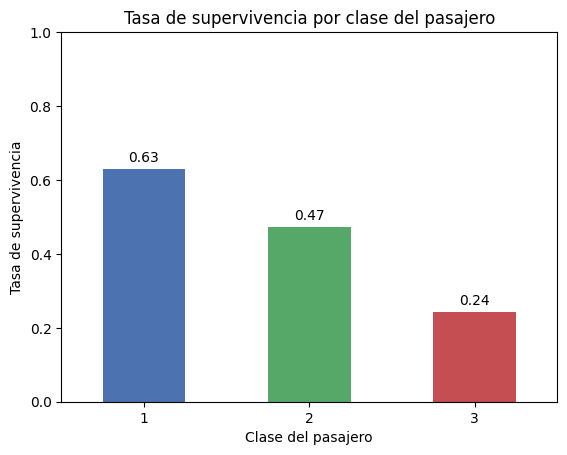

In [11]:
# 1.2 EDA — completen aquí
# (use tantas celdas de código como necesite, pero comente cada decisión)
# 1. Tasa base de supervivencia
tasa_supervivencia = df['Survived'].mean()
print(f"Tasa base de supervivencia: {tasa_supervivencia:.4f}")
print(f"Porcentaje de supervivencia: {tasa_supervivencia*100:.2f}")

print("\nDistribución de clases:")
display(df['Survived'].value_counts(normalize=True))

#2. valores nulos
nulos = df.isnull().mean().sort_values(ascending=False)
display(nulos[nulos > 0])

# Visualización: tasa de supervivencia por clase del pasajero
surv_class = df.groupby('Pclass')['Survived'].mean()

ax = surv_class.plot(
    kind='bar',
    color=['#4C72B0', '#55A868', '#C44E52']
)

plt.title('Tasa de supervivencia por clase del pasajero')
plt.xlabel('Clase del pasajero')
plt.ylabel('Tasa de supervivencia')
plt.xticks(rotation=0)
plt.ylim(0, 1)

# Mostrar el valor encima de cada barra
for i, valor in enumerate(surv_class):
    plt.text(
        i,
        valor + 0.02,
        f'{valor:.2f}',
        ha='center'
    )

plt.show()

## 1.3 Limpieza y preprocesamiento (0.2 pts)

Construyan el dataset listo para modelar. Como mínimo deben:

1. **Eliminar** features que no aportan información para clasificación (ej. `PassengerId`, `Name`, `Ticket`, `Cabin` — justifiquen cuáles eliminan).
2. **Imputar** valores nulos de manera defendible. ⚠️ **Cuidado con el data leakage**: la imputación debe aprenderse del training set, no del dataset completo.
3. **Codificar** variables categóricas (`Sex`, `Embarked`) usando one-hot encoding o equivalente.
4. **Escalar** las features numéricas con `StandardScaler`. ⚠️ Mismo cuidado: ajustar solo en training, transformar en test.

Pueden hacer la limpieza en este orden o usar un `Pipeline` de sklearn. Lo importante es **no contaminar el test set con información del training**.

In [12]:
# 1.3 Limpieza — completen aquí
columnas_eliminar = ['PassengerId', 'Name', 'Ticket', 'Cabin']

# X e y
X = df.drop(columns=columnas_eliminar + ['Survived'])
y = df['Survived']

print("Columnas usadas para modelar:")
print(X.columns.tolist())


Columnas usadas para modelar:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


Se eliminan PassengerId, Name, Ticket y Cabin.
PassengerId es solo un identificador, Name y Ticket tienen alta cardinalidad y no se usaran en este modelo base, y Cabin tiene demasiados valores nulos, por lo que puede introducir ruido o pérdida excesiva de datos.

## 1.4 División train / validation / test (0.1 pts)

Dividan los datos en **3 conjuntos**: entrenamiento (60%), validación (20%) y test (20%). Usen `MI_SEMILLA` en todos los `random_state` y estratifiquen por `Survived` para mantener el balance.

> Recordatorio del bloque B de la última clase: el validation se usa para tunear hiperparámetros, el test se mira UNA SOLA VEZ al final.

In [21]:
# 1.4 Split — completen aquí
# Usen MI_SEMILLA como random_state y stratify=y para mantener proporciones

# Separar variables predictoras y variable objetivo
X = df.drop(columns=['Survived'])
y = df['Survived']

# Primer split: 80% datos temporales y 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=MI_SEMILLA,
    stratify=y
)

# Segundo split: del 80% restante, separar 60% train y 20% validation
# Como validation debe ser 20% del total, usamos test_size=0.25 sobre X_temp
# 0.25 * 80% = 20%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=MI_SEMILLA,
    stratify=y_temp
)

print("Tamaño de entrenamiento:", X_train.shape, y_train.shape)
print("Tamaño de validación:", X_val.shape, y_val.shape)
print("Tamaño de test:", X_test.shape, y_test.shape)

Tamaño de entrenamiento: (534, 11) (534,)
Tamaño de validación: (178, 11) (178,)
Tamaño de test: (179, 11) (179,)


## 1.5 Modelo baseline (0.2 pts)

Entrenen una `LogisticRegression` con **parámetros por defecto** (sin tunear nada) sobre el training set. Reporten:

- Accuracy en training
- Accuracy en validation  
- ¿Hay sobreajuste? Comenten brevemente.

No hay evidencia de sobreajuste, ya que el accuracy en training fue 0.7903 y en validation fue 0.8202, el modelo no memoriza el conjunto de entrenamiento y presenta un rendimiento incluso ligeramente mejor en validación, por lo que generaliza de forma aceptable.

Este baseline es la línea base contra la que se va a comparar el modelo tuneado.

In [22]:
# 1.5 Modelo baseline

# Copias para no modificar los datos originales
X_train_base = X_train.copy()
X_val_base = X_val.copy()

# Eliminar columnas que no usaremos en el modelo
columnas_eliminar = ['PassengerId', 'Name', 'Ticket', 'Cabin']

X_train_base = X_train_base.drop(columns=columnas_eliminar)
X_val_base = X_val_base.drop(columns=columnas_eliminar)

# Separar columnas numéricas y categóricas
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Sex', 'Embarked']

# Imputar valores nulos
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_base[num_cols] = num_imputer.fit_transform(X_train_base[num_cols])
X_val_base[num_cols] = num_imputer.transform(X_val_base[num_cols])

X_train_base[cat_cols] = cat_imputer.fit_transform(X_train_base[cat_cols])
X_val_base[cat_cols] = cat_imputer.transform(X_val_base[cat_cols])

# Convertir variables categóricas a variables numéricas
X_train_base = pd.get_dummies(X_train_base, columns=cat_cols, drop_first=True)
X_val_base = pd.get_dummies(X_val_base, columns=cat_cols, drop_first=True)

# Alinear columnas entre training y validation
X_val_base = X_val_base.reindex(columns=X_train_base.columns, fill_value=0)

# Escalar variables
scaler = StandardScaler()

X_train_base_scaled = scaler.fit_transform(X_train_base)
X_val_base_scaled = scaler.transform(X_val_base)

# Entrenar modelo baseline con parámetros por defecto
baseline_model = LogisticRegression(random_state=MI_SEMILLA)

baseline_model.fit(X_train_base_scaled, y_train)

# Predicciones
y_train_pred_base = baseline_model.predict(X_train_base_scaled)
y_val_pred_base = baseline_model.predict(X_val_base_scaled)

# Accuracy
acc_train_base = accuracy_score(y_train, y_train_pred_base)
acc_val_base = accuracy_score(y_val, y_val_pred_base)

print(f"Accuracy en training: {acc_train_base:.4f}")
print(f"Accuracy en validation: {acc_val_base:.4f}")

Accuracy en training: 0.7903
Accuracy en validation: 0.8202


## 1.6 Modelo regularizado con búsqueda de hiperparámetros (0.3 pts)

Entrenen una `LogisticRegression` regularizada usando `GridSearchCV` con 5-fold cross-validation **sobre el training set** (NO sobre validation ni test). 

Como mínimo, exploren:
- `C`: al menos 5 valores en escala logarítmica entre 0.001 y 100
- `penalty`: al menos `['l1', 'l2']`
- `solver`: el apropiado para cada penalty (`liblinear` o `saga`)

Reporten:
1. Mejor combinación de hiperparámetros
2. Mejor score de CV
3. Score sobre validation set del mejor modelo

> Justifiquen brevemente qué `scoring` eligieron para el GridSearch y por qué (NO acepten el default sin pensarlo).

In [23]:
# 1.6 GridSearchCV

# Modelo base
log_reg = LogisticRegression(
    max_iter=5000,
    random_state=MI_SEMILLA
)

# Grid de hiperparámetros
# liblinear y saga funcionan con l1 y l2
param_grid = [
    {
        'C': np.logspace(-3, 2, 6),   # 0.001 hasta 100
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }
]

# GridSearchCV con 5-fold cross-validation SOLO sobre training
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_base_scaled, y_train)

# Mejor modelo encontrado
best_model = grid_search.best_estimator_

# Predicción en validation
y_val_pred_grid = best_model.predict(X_val_base_scaled)

# Score en validation
validation_score = accuracy_score(y_val, y_val_pred_grid)

print("Mejor combinación de hiperparámetros:")
print(grid_search.best_params_)

print(f"\nMejor score de CV: {grid_search.best_score_:.4f}")
print(f"Score en validation del mejor modelo: {validation_score:.4f}")

Mejor combinación de hiperparámetros:
{'C': np.float64(10.0), 'penalty': 'l2', 'solver': 'liblinear'}

Mejor score de CV: 0.7940
Score en validation del mejor modelo: 0.8258


El mejor modelo encontrado por GridSearchCV utilizó `C = 10.0`, penalización `l2` y solver `liblinear`. El mejor score promedio obtenido en la validación cruzada de 5 folds fue `0.7940`, mientras que el score del mejor modelo sobre el conjunto de validation fue `0.8258`.

Para el GridSearchCV se eligió accuracy como métrica de evaluación, porque en esta etapa se busca comparar el porcentaje general de aciertos del modelo tuneado frente al modelo baseline. Aunque el dataset Titanic no está perfectamente balanceado, la diferencia entre clases no es extrema, por lo que accuracy permite una comparación clara y directa del rendimiento general.

El valor `C = 10.0` indica una regularización relativamente baja, permitiendo que el modelo tenga mayor flexibilidad para ajustarse a los datos. 

La penalización `l2` ayuda a controlar los coeficientes sin eliminarlos completamente

el solver `liblinear` es adecuado para este tipo de problema de clasificación binaria. En comparación con el baseline, que obtuvo un accuracy de `0.8202` en validation, el modelo tuneado mejoró ligeramente hasta `0.8258`. La mejora no es grande, pero sí muestra que la búsqueda de hiperparámetros logró encontrar una configuración un poco más efectiva sin evidenciar sobreajuste.

## 1.7 Métricas completas sobre VALIDATION (0.2 pts)

Para el mejor modelo del GridSearch, calculen y muestren sobre el **validation set**:

1. Accuracy, Precision, Recall, F1, ROC-AUC
2. Matriz de confusión (con `ConfusionMatrixDisplay`, normalizada)
3. Curva precision-recall (con `precision_recall_curve` + plot)

Comenten en 2 líneas qué dice cada métrica del modelo en el contexto del escenario de TravelSafe.

In [25]:
# 1.7 Métricas sobre validation 

# Predicciones del mejor modelo sobre validation
y_val_pred = best_model.predict(X_val_base_scaled)
y_val_proba = best_model.predict_proba(X_val_base_scaled)[:, 1]

# Métricas principales
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
roc_auc_val = roc_auc_score(y_val, y_val_proba)

print("Métricas sobre validation:")
print(f"Accuracy:  {acc_val:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall:    {recall_val:.4f}")
print(f"F1:  {f1_val:.4f}")
print(f"ROC-AUC:   {roc_auc_val:.4f}")

Métricas sobre validation:
Accuracy:  0.8258
Precision: 0.7467
Recall:    0.8235
F1:  0.7832
ROC-AUC:   0.8848


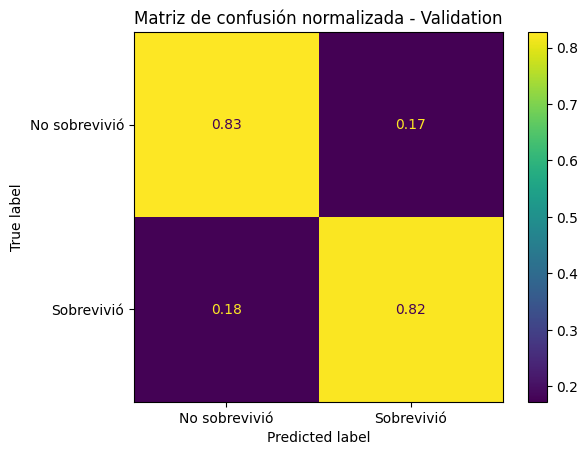

In [26]:
# Matriz de confusión normalizada

cm = confusion_matrix(y_val, y_val_pred, normalize='true')

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No sobrevivió', 'Sobrevivió']
)

disp.plot(values_format='.2f')
plt.title('Matriz de confusión normalizada - Validation')
plt.show()

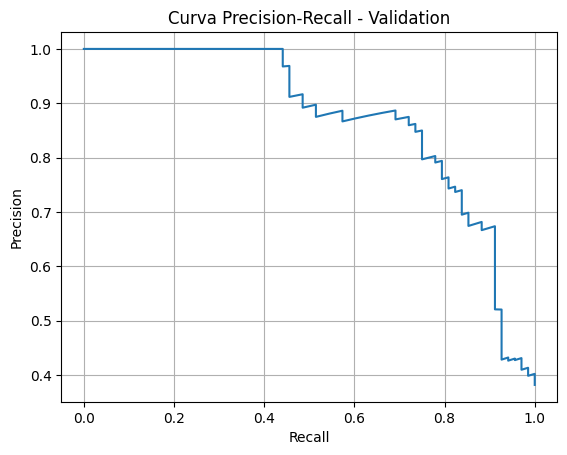

In [27]:
# Curva Precision-Recall

precision_curve, recall_curve, thresholds_curve = precision_recall_curve(
    y_val,
    y_val_proba
)

plt.plot(recall_curve, precision_curve)
plt.title('Curva Precision-Recall - Validation')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

El "accuracy" indica el porcentaje total de aciertos y el "ROC-AUC" mide su capacidad para separar sobrevivientes de no sobrevivientes. En el contexto de TravelSafe, la "precision" es importante porque evita clasificar como sobrevivientes a pasajeros que realmente no sobrevivieron.

El "recall" indica cuántos sobrevivientes reales fueron detectados y el "F1-score" resume el balance entre precision y recall.

## 1.8 Justificación técnica + evaluación FINAL sobre test (0.2 pts)

Esta es la parte más importante. Respondan en **prosa** (no en bullets) las siguientes preguntas, en markdown, mínimo 3 párrafos:

1. **Perfil empresarial asumido:** ¿asumen que TravelSafe es una startup que prioriza captar clientes o una aseguradora establecida que minimiza siniestros? Justifiquen.
2. **Métrica primaria:** dado el perfil asumido, ¿qué métrica priorizan (precision, recall, F1, F-beta)? Si eligen F-beta, ¿qué valor de β y por qué? Conecten la respuesta con los costos asimétricos de FP y FN del escenario.
3. **Threshold:** ¿usarían el threshold por defecto (0.5) o lo moverían? Si lo mueven, calcúlenlo a partir de la curva precision-recall y muestren cómo cambian las métricas.
4. **Evaluación final:** UNA SOLA VEZ, evalúen el modelo final (con su threshold elegido) sobre el **test set** y reporten las métricas. ¿Hay diferencia significativa entre validation y test? ¿Qué dirían los resultados a TravelSafe?

> ⚠️ Una vez que miran el test set, no pueden volver a cambiar el modelo. Si lo hacen, es deshonestidad académica y la evaluación queda en cero.

**Sus respuestas aquí (markdown, mínimo 3 párrafos):**

TravelSafe es una aseguradora que prioriza minimizar siniestros y controlar el riesgo financiero, en este caso, la empresa debe evitar decisiones demasiado optimistas al clasificar a un pasajero como “sobreviviente”, porque esa predicción podría llevar a cobrar una prima más baja a una persona que realmente representa mayor riesgo.

La métrica primaria que priorizo es "precision", complementada con "F-beta" usando β = 0.5, porque este valor da más peso a la precision que al recall. En este escenario, un falso positivo es costoso: el modelo predice que el pasajero sobreviviría, pero realmente no sobrevivió, lo que puede hacer que TravelSafe subestime el riesgo. Por eso, se eligió un threshold de "0.6146", calculado desde la curva precision-recall, buscando mantener una precision mínima cercana a 0.80.

Con el threshold elegido, en validation el modelo obtuvo "accuracy = 0.8427", "precision = 0.8030", "recall = 0.7794", "F1 = 0.7910", "F-beta 0.5 = 0.7982" y "ROC-AUC = 0.8848". Al evaluar una sola vez sobre test, obtuvo "accuracy = 0.7989", "precision = 0.8113", "recall = 0.6232", "F1 = 0.7049", "F-beta 0.5 = 0.7651" y "ROC-AUC = 0.8321". La precision se mantuvo incluso ligeramente más alta en test, pero el recall bajó de forma notable, lo que indica que el modelo fue más conservador y dejó pasar más sobrevivientes reales. Para TravelSafe, esto significa que el modelo es útil para controlar riesgo, aunque sacrifica captación de clientes y debería usarse como apoyo, no como única herramienta de decisión.

In [28]:
# 1.8 Evaluación final sobre test set — UNA SOLA VEZ

# Probabilidades del mejor modelo en validation
y_val_proba = best_model.predict_proba(X_val_base_scaled)[:, 1]

# Curva precision-recall sobre validation
precision_vals, recall_vals, thresholds_vals = precision_recall_curve(
    y_val,
    y_val_proba
)

# Elegimos un threshold que priorice precision
# Buscamos precision mínima de 0.80 y el mayor recall posible
target_precision = 0.80

valid_idx = np.where(precision_vals[:-1] >= target_precision)[0]

if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(recall_vals[valid_idx])]
    chosen_threshold = thresholds_vals[best_idx]
else:
    chosen_threshold = 0.5

print(f"Threshold elegido: {chosen_threshold:.4f}")

# Métricas en validation con threshold elegido
y_val_pred_threshold = (y_val_proba >= chosen_threshold).astype(int)

print("\nMétricas en VALIDATION con threshold elegido:")
print(f"Accuracy:   {accuracy_score(y_val, y_val_pred_threshold):.4f}")
print(f"Precision:  {precision_score(y_val, y_val_pred_threshold):.4f}")
print(f"Recall:     {recall_score(y_val, y_val_pred_threshold):.4f}")
print(f"F1-score:   {f1_score(y_val, y_val_pred_threshold):.4f}")
print(f"F-beta 0.5: {fbeta_score(y_val, y_val_pred_threshold, beta=0.5):.4f}")
print(f"ROC-AUC:    {roc_auc_score(y_val, y_val_proba):.4f}")

# Preparar X_test igual que training y validation
X_test_base = X_test.copy()

columnas_eliminar = ['PassengerId', 'Name', 'Ticket', 'Cabin']
X_test_base = X_test_base.drop(columns=columnas_eliminar)

X_test_base[num_cols] = num_imputer.transform(X_test_base[num_cols])
X_test_base[cat_cols] = cat_imputer.transform(X_test_base[cat_cols])

X_test_base = pd.get_dummies(X_test_base, columns=cat_cols, drop_first=True)
X_test_base = X_test_base.reindex(columns=X_train_base.columns, fill_value=0)

X_test_base_scaled = scaler.transform(X_test_base)

# Evaluación FINAL sobre test set — UNA SOLA VEZ
y_test_proba = best_model.predict_proba(X_test_base_scaled)[:, 1]
y_test_pred_final = (y_test_proba >= chosen_threshold).astype(int)

print("\nMétricas FINALES sobre TEST:")
print(f"Accuracy:   {accuracy_score(y_test, y_test_pred_final):.4f}")
print(f"Precision:  {precision_score(y_test, y_test_pred_final):.4f}")
print(f"Recall:     {recall_score(y_test, y_test_pred_final):.4f}")
print(f"F1-score:   {f1_score(y_test, y_test_pred_final):.4f}")
print(f"F-beta 0.5: {fbeta_score(y_test, y_test_pred_final, beta=0.5):.4f}")
print(f"ROC-AUC:    {roc_auc_score(y_test, y_test_proba):.4f}")

Threshold elegido: 0.6146

Métricas en VALIDATION con threshold elegido:
Accuracy:   0.8427
Precision:  0.8030
Recall:     0.7794
F1-score:   0.7910
F-beta 0.5: 0.7982
ROC-AUC:    0.8848

Métricas FINALES sobre TEST:
Accuracy:   0.7989
Precision:  0.8113
Recall:     0.6232
F1-score:   0.7049
F-beta 0.5: 0.7651
ROC-AUC:    0.8321


---

# 🐛 PARTE 2 — Find the bug + Predict the output (0.75 puntos · ~20 min)

En esta parte hay **5 celdas de código**. Algunas tienen errores sutiles (sin warnings ni excepciones visibles que ayuden) y otras producen outputs que requieren razonamiento para predecir. 

**Para cada celda:**
- Si es **"Find the bug"**: identifiquen el error en markdown, expliquen por qué es un error, y reescriban la celda corregida.
- Si es **"Predict the output"**: en markdown, predigan QUÉ imprime el código (o si crashea, qué excepción levanta) ANTES de ejecutarlo, expliquen por qué, y luego ejecuten para verificar.

> Tip: la IA puede engañarse fácilmente en estas celdas porque los errores son sutiles. Léanlas con atención.

---

## 2.1 Find the bug (0.15 pts)

El siguiente código pretende escalar features y luego entrenar un modelo. ¿Qué problema tiene? Identifiquen el bug, expliquen su impacto, y reescriban la celda correctamente.

In [ ]:
# === CELDA 2.1 — Find the bug (NO la corrijan aquí, copien abajo y corrijan) ===
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
print(f"Accuracy test: {model.score(X_test, y_test):.4f}")

**🔍 Su análisis del bug 2.1:**

*[¿Cuál es el bug? ¿Por qué es un problema? ¿Qué impacto tiene en producción?]*

In [ ]:
# Versión corregida de la celda 2.1 — completen aquí


## 2.2 Find the bug (0.15 pts)

Este código intenta imputar valores nulos y dividir el dataset. Hay un bug sutil que produce data leakage. Identifíquenlo y corríjanlo.

In [ ]:
# === CELDA 2.2 — Find the bug ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Imputar Age con la media
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Codificar Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Media de Age en train: {X_train['Age'].mean():.2f}")
print(f"Media de Age en test:  {X_test['Age'].mean():.2f}")

**🔍 Su análisis del bug 2.2:**

*[¿Cuál es el bug? ¿Cómo se manifiesta? ¿Qué consecuencia tiene en métricas reales?]*

In [ ]:
# Versión corregida de la celda 2.2 — completen aquí


## 2.3 Predict the output (0.15 pts)

¿Qué imprime exactamente el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.3:**

*[¿Qué imprime? ¿Por qué?]*

In [ ]:
# === CELDA 2.3 — Predict the output ===
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

valores = [0, 5, -5, 50, -50, 1000]
for v in valores:
    print(f"sigmoid({v:>5}) = {sigmoid(v)}")

## 2.4 Find the bug (0.15 pts)

Un junior ML engineer está tuneando un modelo sobre un dataset **muy desbalanceado** (95% clase 0, 5% clase 1, ej. detección de fraude). Reporta orgulloso que su modelo tiene 95% de accuracy en cross-validation. ¿Cuál es el problema?

In [ ]:
# === CELDA 2.4 — Find the bug ===
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

# Generamos un dataset MUY desbalanceado: 95% clase 0, 5% clase 1
X, y = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

model = LogisticRegression(max_iter=5000)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

print(f"Mejor C: {grid_search.best_params_['C']}")
print(f"Mejor accuracy: {grid_search.best_score_:.4f}")

**🔍 Su análisis del bug 2.4:**

*[¿Por qué 95% de accuracy es engañoso aquí? ¿Qué métrica deberían usar? ¿Qué pasa si entreno un modelo que SIEMPRE predice clase 0?]*

In [ ]:
# Versión corregida de la celda 2.4 — completen aquí


## 2.5 Predict the output (0.15 pts)

¿Qué imprime el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.5:**

*[¿Qué pasa al ejecutar esto? Si crashea, ¿qué error? Si imprime algo, ¿qué?]*

In [ ]:
# === CELDA 2.5 — Predict the output ===
import numpy as np

# Vector de recall en función del threshold (decreciente, máximo 0.95)
recall = np.array([0.95, 0.90, 0.82, 0.71, 0.50, 0.30, 0.10])
thresholds = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])

target_recall = 1.0
idx = np.where(recall[:-1] >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

print(f"Threshold óptimo: {optimal_threshold}")

---

# 💼 PARTE 3 — Trade-offs de negocio (0.75 puntos · ~20 min)

Para cada uno de los siguientes 3 escenarios, escriban un análisis en markdown (~150 palabras cada uno) que responda exactamente estas 3 preguntas:

1. **¿Cuál es más costoso, un FP o un FN?** Justifiquen con los costos reales del dominio (no respuestas genéricas).
2. **¿Qué métrica priorizan y qué valor de β usarían en el F-beta?** Conecten con la fórmula y el razonamiento de los costos.
3. **¿El threshold por defecto de 0.5 es apropiado, o lo moverían? ¿En qué dirección?**

> ⚠️ La IA da respuestas genéricas a estas preguntas. Lo que diferencia una respuesta de 0.25 pts de una de 0.10 es la **especificidad del razonamiento al dominio concreto**. Si su respuesta funciona idéntica para los 3 escenarios, está mal.

---

## 3.1 Escenario A — Detección de fraude en tarjeta de crédito (0.25 pts)

**Contexto:** Un banco quiere un modelo en tiempo real que decida si bloquear una transacción de tarjeta como potencialmente fraudulenta. Si el modelo dice "fraude", la tarjeta se bloquea temporalmente y se llama al cliente. Si dice "legítima", la transacción se procesa normalmente. Solo el 0.5% de las transacciones reales son fraude. Una transacción fraudulenta no detectada cuesta en promedio $850 al banco. Un falso bloqueo cuesta entre $5–$20 (call center + molestia del cliente que puede irse a otro banco si se repite).

**Su análisis:**

*[completar]*

---

## 3.2 Escenario B — Recomendador de películas en streaming (0.25 pts)

**Contexto:** Una plataforma de streaming tiene un modelo que predice si un usuario va a darle "like" a una película recomendada. Solo se muestran las películas con probabilidad alta de gustar. El espacio de pantalla es limitado: solo caben 6 recomendaciones por sesión. Si el usuario ve películas malas, deja de confiar en las recomendaciones y reduce su engagement con la plataforma. Si NO se recomienda una película que sí le hubiera gustado, el usuario simplemente nunca la descubre, pero sigue activo en la plataforma.

**Su análisis:**

*[completar]*

---

## 3.3 Escenario C — Triage automático de neumonía por radiografía (0.25 pts)

**Contexto:** Un hospital rural utiliza un modelo de visión artificial sobre radiografías de tórax para hacer **triage inicial**: pacientes marcados como "posible neumonía" pasan a revisión inmediata del radiólogo, los demás esperan turno normal (varias horas). La población incluye muchos adultos mayores. Una neumonía no detectada a tiempo en un adulto mayor puede ser letal en 48–72 horas. Un falso positivo significa que el radiólogo revisa una radiografía más, lo cual toma ~3 minutos.

**Su análisis:**

*[completar]*

---

# ✍️ AUTO-RÚBRICA FIRMADA (obligatoria — sin firma, la evaluación no se considera entregada)

Califíquense honestamente. Cada criterio tiene puntaje binario o fraccionario. Sumen al final.

## Parte 1 — Pipeline (máx. 1.5)

| Criterio | Máx | Mi nota |
|---|---|---|
| 1.1 Carga + EDA básico sin errores | 0.10 |  |
| 1.2 EDA dirigido con al menos 1 visualización comentada | 0.20 |  |
| 1.3 Limpieza correcta (encoding, imputación, scaling SIN data leakage) | 0.20 |  |
| 1.4 Split 60/20/20 con MI_SEMILLA y estratificación | 0.10 |  |
| 1.5 Baseline ejecutado y comentado (over/underfitting discutido) | 0.20 |  |
| 1.6 GridSearchCV con justificación del scoring elegido | 0.30 |  |
| 1.7 Las 5 métricas + matriz de confusión + curva PR sobre validation | 0.20 |  |
| 1.8 Justificación técnica de β/threshold + evaluación final test (1 vez) | 0.20 |  |
| **Subtotal Parte 1** | **1.50** |  |

## Parte 2 — Bugs y outputs (máx. 0.75)

| Criterio | Máx | Mi nota |
|---|---|---|
| 2.1 Identificó data leakage del scaler antes del split + corrigió | 0.15 |  |
| 2.2 Identificó data leakage de fillna(mean) antes del split + corrigió | 0.15 |  |
| 2.3 Predijo correctamente el output de sigmoid en valores extremos | 0.15 |  |
| 2.4 Identificó que accuracy es engañosa en dataset desbalanceado | 0.15 |  |
| 2.5 Predijo correctamente el IndexError de np.where | 0.15 |  |
| **Subtotal Parte 2** | **0.75** |  |

## Parte 3 — Trade-offs (máx. 0.75)

Para cada escenario, califíquense así:
- **0.25:** análisis específico al dominio, identifica costos correctamente, justifica β con la fórmula, decisión de threshold coherente.
- **0.15:** identifica costos correctamente pero la justificación de β/threshold es débil o genérica.
- **0.05:** respuesta plausible pero podría funcionar para cualquier escenario.
- **0.00:** vacío o incorrecto.

| Criterio | Máx | Mi nota |
|---|---|---|
| 3.1 Análisis fraude bancario | 0.25 |  |
| 3.2 Análisis recomendador streaming | 0.25 |  |
| 3.3 Análisis triage neumonía | 0.25 |  |
| **Subtotal Parte 3** | **0.75** |  |

---

## NOTA TOTAL: _____ / 3.0

---

## Declaración de honestidad académica

*Yo, **[NOMBRE COMPLETO]**, con cédula **[CÉDULA]**, declaro que:*

1. *La semilla `MI_SEMILLA` corresponde a los últimos 4 dígitos de mi cédula.*
2. *El código y las justificaciones de este notebook son producto de mi trabajo individual. Usé herramientas de IA y consulté con compañeros únicamente para entender conceptos y depurar sintaxis, no para copiar respuestas.*
3. *Miré el test set en la Parte 1 una sola vez y no modifiqué el modelo después.*
4. *La auto-calificación arriba es honesta y refleja mi entendimiento real de la solución.*

**Firma (escribir nombre completo aquí):** ___________________________

**Fecha y hora de finalización:** ___________________________

---

## Checklist antes de hacer push final

- [ ] Reemplacé `MI_SEMILLA = 0000` con mis últimos 4 dígitos de cédula
- [ ] Todas las celdas de código corren sin errores (Restart kernel + Run all)
- [ ] Hice commit con mensaje claro de cada parte completada
- [ ] La auto-rúbrica está completa y firmada
- [ ] Hice `git push origin eval-titanic`